# LOO-CV tutorial for RV analysis

In this notebook we will demonstrate how to carry out leave-one-out cross-validation (LOO-CV) using the Pareto-smoothed importance sampling (PSIS) approximation. We will perform a LOO-CV analysis of CARMENES RV data for the GJ 4276 system (Nagel et al. 2019). We will use the arviz package to do so. We begin by importing the relevant packages:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az               #main package required for LOO-CV

The main object that we require for LOO-CV is the pointwise log likelihood for a set of equally-weighted posterior samples. This can be generated after an RV model fit has been completed by iterating through your equally weighted posteriors and calculating the likelihood function (without summing over wavelengths) for each sample. Alternatively, you can generate binned model realisations for each sample and calculate the likelihood afterwards.

In this case, we will perform LOO-CV for two different models: a single-planet model and a two-planet model. We load the log-likelihoods here (note that you will need to download the auxiliary data and place it in the appropriate directory):

In [2]:
#Log Likelihoods for the single-planet model
loglike_1pl = np.load('auxiliary_data/loglikelihood_per_datapoint_single_planet.npy')

loglike_2pl = np.load('auxiliary_data/loglikelihood_per_datapoint_two_planet.npy')

print(loglike_1pl.shape)
print(loglike_2pl.shape)

(92215, 100)
(89366, 100)


We can see that each array consists of a number of posterior samples, each with 100 values representing the likelihood function calculated for each individual RV measurement.

In order to use the arviz loo function, we need to format our data appropriately. We create an Inference Data object containing the log likelihoods, and a placeholder for the posteriors (this is not needed in the LOO-CV calculation).

In [3]:
#Add an extra dimension to each likelihood array so that they are read correctly by arviz
loglike_1pl_converted = np.expand_dims(loglike_1pl,0)
loglike_2pl_converted = np.expand_dims(loglike_2pl,0)

#Create Inference Data objects the likelihoods, and add a placeholder posterior group
loglike_1pl_data = az.convert_to_inference_data(loglike_1pl_converted,group='log_likelihood')
loglike_1pl_data.add_groups(posterior = {"placeholder": np.ones_like(loglike_1pl_converted)})

loglike_2pl_data = az.convert_to_inference_data(loglike_2pl_converted,group='log_likelihood')
loglike_2pl_data.add_groups(posterior = {"placeholder": np.ones_like(loglike_2pl_converted)})

Now we can carry out LOO-CV. We can also check a summary of the calculation to ensure that the Pareto k diagnostics are ok. If the Pareto k value exceeds 0.7 for any data point, it is recommended to re-run your RV fit without that data point rather than relying on the PSIS approximation to calculate the expected log predictive density (ELPD). We can start with the single-planet case:

In [4]:
loo_1pl = az.loo(loglike_1pl_data, var_name = 'x', pointwise = True)
loo_1pl

Computed from 92215 posterior samples and 100 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -267.82    15.02
p_loo       23.69        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      100  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

Here we find that the Pareto k does not exceed 0.7, so we don't need to worry about running additional fits. We can inspect the elpd scores for each data point and store them in a numpy array.

In [5]:
loo_i_1pl = np.copy(loo_1pl.loo_i)
print(loo_i_1pl)

[-3.38008191 -2.0260373  -2.17235367 -1.75995386 -4.56907671 -2.11502916
 -1.56025098 -2.29068782 -2.17937738 -1.75636663 -1.46657767 -4.84873774
 -2.74197932 -1.97272227 -1.5739599  -1.60509188 -1.3176238  -1.31836487
 -3.49275025 -1.85051975 -1.63436154 -2.75225105 -2.48851112 -4.74830629
 -4.24289968 -1.71232363 -2.67545781 -1.38764991 -1.68532977 -7.45640051
 -7.85903194 -3.04876126 -6.60976088 -4.12540777 -2.6551754  -2.45055698
 -1.89071951 -3.92810793 -2.71168832 -2.64456486 -4.29610413 -1.67094248
 -1.57510467 -9.72812104 -1.74941411 -3.56830489 -4.67449739 -6.08943918
 -1.69307    -1.46080656 -2.1530715  -1.65393844 -1.76714519 -3.00970929
 -3.20901116 -2.4959482  -1.61346227 -1.62495241 -2.12672658 -1.64980851
 -2.66231033 -1.65782078 -2.32185277 -2.04318221 -1.66225155 -5.21963056
 -1.9599513  -3.17664662 -1.83872463 -1.6436201  -1.74113784 -1.54109676
 -1.78410283 -1.53579587 -5.20413454 -1.50776918 -1.73627994 -3.07985378
 -2.03928181 -1.88670169 -4.05349071 -1.81307789 -2

Now we move on to the two-planet case:

In [6]:
loo_2pl = az.loo(loglike_2pl_data, var_name = 'x', pointwise = True)
loo_2pl

/Users/matthewnixon/miniforge3/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 89366 posterior samples and 100 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -282.71    16.12
p_loo       36.24        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       98   98.0%
   (0.70, 1]   (bad)         2    2.0%
   (1, Inf)   (very bad)    0    0.0%

This time, the LOO-CV calculation produced a warning, since two of the data points resulted in a shape parameter k > 0.7. This means that a full refit is required to find an accurate ELPD for these data points under this model. Let's figure out what data points we need to refit:

In [7]:
#Convert the output values of k into a numpy array
pareto_k_2pl = np.copy(loo_2pl.pareto_k)

#Check which indices yield k>0.7
print(np.argwhere(pareto_k_2pl>0.7))

[[ 4]
 [89]]


So, we need to refit the two-planet model to the dataset two more times, once leaving out the data point at index 4, and once leaving out the data point at index 89. Once this is done, we then evaluate the likelihood of the model fit without that data point to the data point itself. The ELPD is simply the average log-likelihood for that missing data point across all posterior samples. For illustrative purposes, we have provided the per-data-point log-likelihoods for our RV model fit to the data with each point removed.

In [8]:
#Load the log-likelihoods fit to the data with points 4 and 89 removed, evaluated on the whole data set
loglike_x04 = np.load('auxiliary_data/loglikelihood_idx_4_left_out.npy')
loglike_x89 = np.load('auxiliary_data/loglikelihood_idx_89_left_out.npy')

#The ELPD score for each point is the log-likelihood of the model fit with a data point removed, evaluated on that data point
loo_04 = np.mean(loglike_x04[:,4])
loo_89 = np.mean(loglike_x89[:,89])

#Create an array of the ELPD values from arviz, and replace the two problematic entries with the newly-computed values
loo_i_2pl_arviz = np.copy(loo_2pl.loo_i)

loo_i_2pl = np.copy(loo_i_2pl_arviz)

loo_i_2pl[4] = loo_04
loo_i_2pl[89] = loo_89

print(loo_i_2pl)

[-2.97150024 -2.04311299 -2.25847619 -2.23813176 -6.88425709 -1.93228127
 -1.66688016 -3.1887133  -2.37056787 -2.52783795 -1.59158543 -5.92893677
 -1.89530754 -2.11531893 -1.51149505 -1.57061459 -1.35648267 -2.10044678
 -2.28610839 -2.84025819 -1.75020747 -3.20020188 -2.97551552 -3.59863942
 -6.16460448 -2.30525562 -3.0195559  -2.02230449 -1.46832471 -7.52996629
 -5.84678351 -2.38232306 -7.15487433 -4.54587658 -2.43820442 -2.27707984
 -1.87203555 -4.84932883 -2.77634227 -2.09110596 -6.9146804  -2.0886698
 -2.31443849 -9.9780971  -2.47478263 -4.15548486 -3.08064723 -4.17006933
 -1.53497421 -1.5228219  -2.0358646  -2.14039674 -1.33544478 -2.47386338
 -2.9288752  -2.62750985 -1.9918521  -1.71625701 -2.20614469 -1.66333821
 -2.35683561 -1.57121803 -1.69007207 -2.16970609 -1.61565983 -4.32053961
 -2.65618313 -3.85107316 -1.86454817 -1.55515252 -2.19798645 -1.6116369
 -2.64129017 -2.12425726 -5.11090633 -1.53379934 -1.89360786 -3.76460211
 -2.02719387 -1.71817621 -3.09854745 -1.66520018 -2.5

Now we can calculate the difference in ELPD scores between the two models, as well as its standard error:

In [9]:
delta_elpd_i = loo_i_1pl - loo_i_2pl

delta_elpd = np.sum(delta_elpd_i)
se_delta_elpd = np.power(len(delta_elpd_i)*np.var(delta_elpd_i),0.5)

print(f"The difference in ELPD is {delta_elpd:.2f} in favour of the single-planet model, with a standard error of {se_delta_elpd:.2f}.")

The difference in ELPD is 14.19 in favour of the single-planet model, with a standard error of 7.72.


Finally, we can visualise the difference in ELPD at the per-data-point level with a figure.

(-18.0, 18.0)

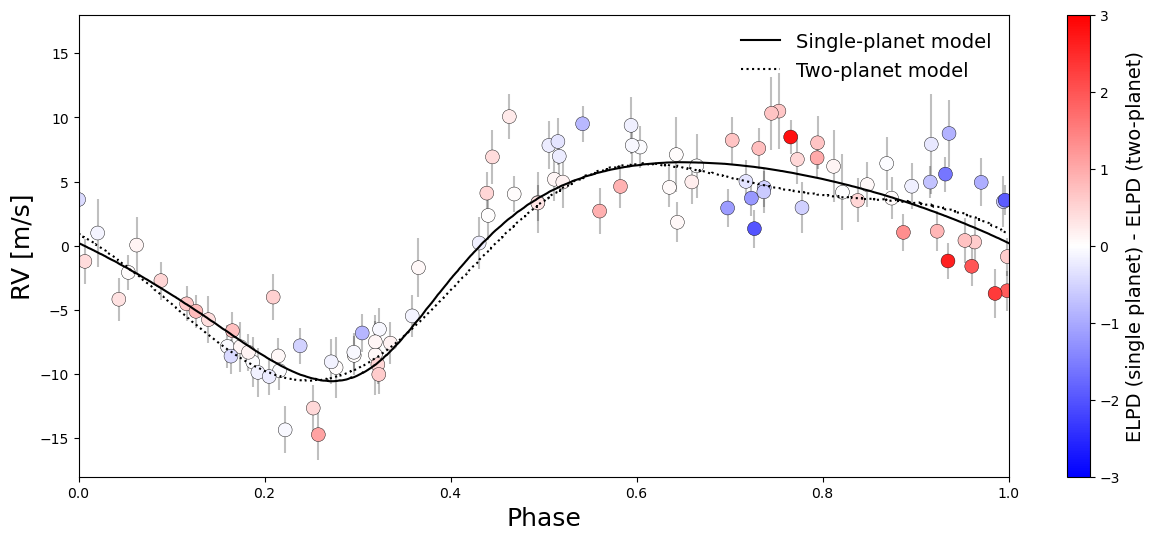

In [10]:
rv_data = np.loadtxt('auxiliary_data/CARMENES_RV_GJ4276.dat',usecols=(0,1,2))
time = rv_data[:,0]
rv = rv_data[:,1]
err = rv_data[:,2]

period = 13.352 #Here we are using the orbital period (in days) from the single-planet solution for visualisation purposes

phase = ((time - time[0]) % period)/period

idx = np.argsort(np.abs(delta_elpd_i))

#Create figure and axis
fig = plt.figure(figsize=(15,6))
ax1 = plt.gca()

#Plot RV data, with colour set by value of delta ELPD
plt.errorbar(phase, rv,yerr=err,fmt='o',markersize=0,alpha=0.25,color='k',zorder=0.0000001)
plt.scatter(phase[idx], rv[idx] ,c=delta_elpd_i[idx],cmap='bwr',linewidth=0.3,edgecolor='k',zorder=0.1,vmin=-3,vmax=3,s=100)

#Add best-fit single-planet and two-planet models for comparison
single_planet_model = np.loadtxt('auxiliary_data/single_planet_best_fit.txt') #Format is [phase, RV]
plt.plot(single_planet_model[:,0],single_planet_model[:,1],color='k',label='Single-planet model')

two_planet_model = np.loadtxt('auxiliary_data/two_planet_best_fit.txt')
plt.plot(two_planet_model[:,0],two_planet_model[:,1],color='k',ls='dotted',label='Two-planet model')

plt.legend(fontsize=14,frameon=False)

#Add colour bar
cbar = plt.colorbar()
cbar.ax.set_ylabel('ELPD (single planet) - ELPD (two-planet)',fontsize=14)

#Axis labels and limits
ax1.set_ylabel('RV [m/s]', fontsize=18)
ax1.set_xlabel('Phase', fontsize=18)

ax1.set_xlim(0,1)
ax1.set_ylim(-18,18)